In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Variable

import cv2
import numpy as np
import time
from PIL import Image

from SAM.modeling.mask_decoder import MaskDecoder
from SAM.modeling.prompt_encoder import PromptEncoder
from SAM.modeling.transformer import TwoWayTransformer
from SAM.modeling.common import LayerNorm2d
from typing import List, Tuple, Type, Optional
# from SAM.modeling.student_encoder import SemiTViT

from torchmetrics.classification import BinaryAccuracy, BinaryJaccardIndex
from torch.optim import lr_scheduler

import os
from tqdm import tqdm
from collections import OrderedDict
# from functools import partial
# from timm.models import create_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
## DIY modules
from SAM.modules.modality_inspector import Modality_Inspector
from SAM.modules.normalized_bbox_regressor import NormalizedBBoxRegressor

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
device

device(type='cuda')

In [5]:
## load pretrained models
checkpoint = torch.load("best_mobile_modality_inspector_model.pth", map_location=device)
modality_inspector = Modality_Inspector(num_classes=6).to(device)
modality_inspector.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [6]:
checkpoint = torch.load("best_normalized_bbox_model.pth", map_location=device)
new_state_dict = OrderedDict()

for k, v in checkpoint['model_state_dict'].items():
    new_key = k.replace("module.", "")
    new_state_dict[new_key] = v

bbox_generator = NormalizedBBoxRegressor().to(device)
bbox_generator.load_state_dict(new_state_dict)

<All keys matched successfully>

In [7]:
class ESPMedSAM(nn.Module):
    
    def __init__(self, modality_inspector = None, bbox_generator = None):
        
        super(ESPMedSAM, self).__init__()

        # self.SemiTViT = SemiTViT(img_size=1024, in_chans=3, num_classes=1000,
        #         embed_dims=[64, 128, 160, 320],
        #         depths=[2, 2, 6, 2],
        #         num_heads=[2, 4, 5, 10],
        #         window_sizes=[7, 7, 14, 7],
        #         mlp_ratio=4.,
        #         drop_rate=0.,
        #         drop_path_rate=0.0,
        #         use_checkpoint=False,
        #         mbconv_expand_ratio=4.0,
        #         local_conv_size=3,
        #         layer_lr_decay=0.8
        #     )

        self.modality_inspector = modality_inspector
        self.bbox_generator = bbox_generator

        self.prompt_encoder = PromptEncoder(
            embed_dim=256,
            image_embedding_size=(64, 64), # 1024 // 16
            input_image_size=(1024, 1024),
            mask_in_chans=16,
            )
        
        self.mask_decoder = MaskDecoder(
            transformer=TwoWayTransformer(
                depth=2,
                embedding_dim=256,
                mlp_dim=2048,
                num_heads=8,
            ),
            transformer_dim=256,
            )

        ## input h/2 w/2
        self.patch_decoder = nn.Sequential(nn.Conv2d(256, 64, kernel_size=2, stride=2),
            LayerNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 1, kernel_size=1))
        
        self.dense_prompter = nn.Sequential(nn.Conv2d(1, 256, kernel_size=1),
            LayerNorm2d(256),
            nn.GELU())

        self.num_mask_tokens = 7
        self.mask_query = nn.Embedding(self.num_mask_tokens, 256)


    ## modified input as the mobileSAM image embedding
    def forward(self, image_embeddings, img_id=None):

        # b = x.shape[0]
        b = image_embeddings.shape[0]
        
        # image_embeddings = self.SemiTViT(x)
        bbox_output = self.bbox_generator(image_embeddings)
        # print("bbox_output output: ", bbox_output)

        modality_prob = self.modality_inspector(image_embeddings)
        _, domain_seq = torch.max(modality_prob.data, 1)
        # print("domain_seq output:", domain_seq)
        
        ## used for patch decoder training
        patch_map = self.patch_decoder(image_embeddings)
        
        ## 梯度在此截断(.detach()复制tensor, 截断梯度)
        prob_map = torch.sigmoid(patch_map.detach())
        prob_map[prob_map >= 0.5] = 1
        prob_map[prob_map < 0.5] = 0
        prob_map = F.interpolate(prob_map, scale_factor=2)
        
        patch_embeddings = self.dense_prompter(prob_map)
        
        outputs_mask = []

        for idx in range(b): # for each image in batch 

            image_embeddings_dec = image_embeddings[idx].unsqueeze(0)


            ###########
            ### 看起来对于没有 point box mask的情况下，这段代码没有用。
            ###########
            
            sparse_embeddings, dense_embeddings = self.prompt_encoder(
                points=None,
                boxes=None,
                masks=None,
            )

            image_pe = self.prompt_encoder.get_dense_pe()
            
            ############
            ###
            ############

            # Mask 
            mask_tokens = self.mask_query.weight
            mask_tokens = mask_tokens.unsqueeze(0).expand(sparse_embeddings.size(0), -1, -1)
            tokens_mask = torch.cat((mask_tokens, sparse_embeddings), dim=1) # 1 x 5 x 256

            # Expand per-image data in batch direction to be per-mask
            mask_src = torch.repeat_interleave(image_embeddings_dec, tokens_mask.shape[0], dim=0)
            mask_src = mask_src + patch_embeddings[idx].unsqueeze(0) # 1 x 256 x 64 x 64
            mask_pos_src = torch.repeat_interleave(image_pe, tokens_mask.shape[0], dim=0)  # 1 x 256 x 64 x 64

            low_res_masks = self.mask_decoder(
                src=mask_src,
                pos_src=mask_pos_src,
                tokens=tokens_mask,
                mcls=domain_seq[idx] #[idx]
            )

            masks = F.interpolate(low_res_masks, (1024, 1024), mode="bilinear", align_corners=False)
            outputs_mask.append(masks.squeeze(0))

        return torch.stack(outputs_mask, dim=0).squeeze(1), patch_map.squeeze(1), bbox_output, domain_seq

In [8]:
data_label_dic = {
    "CVC_ClinicDB" : 0, # Colonoscopy   - 612 img / 612 mask
    "Darwin": 1,        # X-ray         - 6106 img / 6106 mask
    "DRIVE": 2,         # Fundus        - 40 img / 40 mask
    "DSB_2018": 3,      # Microscopy    - 670 img / 670 mask
    "ISIC_2018": 4,     # Dermoscopy    - 3694 img / 3694 mask
    "Montgomery": 1,    # X-ray         - 138 img / 138 mask
    "PCXA": 1,          # X-ray         - 55 img / 55 mask
    "Shenzhen" : 1,     # X-ray         - 566 img / 566 mask
    "UDIAT" : 5         # Ultrasound    - 163 img / 163 mask
}

idx_name = {
    0: "Colonoscopy",
    1: "X-ray",
    2: "Fundus",
    3: "Microscopy",
    4: "Dermoscopy",
    5: "Ultrasound"
}

In [9]:
# 医疗图像数据集类
class Medcial_Dataset(Dataset):
    
    def __init__(self, files, labels, folder="../SAM_mobile_features/image_feature"):
        self.folder = folder
        self.files = files
        self.labels = labels
        self.image_size = 1024
    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        # image embedding loading
        image_embedding_path = os.path.join(self.folder, self.files[idx])
        image_embedding = torch.load(image_embedding_path)

        # image mask loading
        elems = self.files[idx].split("_set_file_")
        mask_path = f"../datasets/{elems[0]}/mask/{elems[1].split(".")[0]}.png"
        mask = Image.open(mask_path).convert('L')
        mask = np.array(mask)
        mask = cv2.resize(mask, (self.image_size, self.image_size), 
                             interpolation=cv2.INTER_NEAREST)
        mask[mask>0]=255
        mask = mask/255

        # image class output
        label = self.labels[idx]
        
        return image_embedding, mask, label

In [10]:
datafolder = "../SAM_mobile_features/image_feature"

files = os.listdir(datafolder)
labels = []
for f in files:
    labels.append(data_label_dic[f.split("_set_file_")[0]])

X_train, X_val, y_train, y_val = train_test_split(
    files, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [11]:
train_dataset = Medcial_Dataset(X_train, y_train)
val_dataset = Medcial_Dataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=10)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=10)

## 评测标准
iou_metric = BinaryJaccardIndex().to(device)
acc_metric = BinaryAccuracy(multidim_average='samplewise').to(device)

dataloaders = {
    "train": train_loader,
    "valid": val_loader
}

In [12]:
class DiceLoss(nn.Module):
    """Calculate dice loss."""
    def __init__(self, eps: float = 1e-9):
        super(DiceLoss, self).__init__()
        self.eps = eps
        
    def forward(self,
                logits: torch.Tensor,
                targets: torch.Tensor) -> torch.Tensor:
        
        num = targets.size(0)
        probability = torch.sigmoid(logits)
        probability = probability.view(num, -1)
        targets = targets.view(num, -1)
        assert(probability.shape == targets.shape)
        
        intersection = 2.0 * (probability * targets).sum()
        union = probability.sum() + targets.sum()
        dice_score = (intersection + self.eps) / union
        #print("intersection", intersection, union, dice_score)
        return 1.0 - dice_score
        
        
class BCEDiceLoss(nn.Module):
    """Compute objective loss: BCE loss + DICE loss."""
    def __init__(self):
        super(BCEDiceLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        
    def forward(self, 
                logits: torch.Tensor,
                targets: torch.Tensor) -> torch.Tensor:
        assert(logits.shape == targets.shape)
        dice_loss = self.dice(logits, targets)
        bce_loss = self.bce(logits, targets)
        
        return bce_loss + dice_loss

In [13]:
def train_model(model, optimizer, scheduler, criterion, num_epochs = 10):
    since = time.time()
    
    Loss_list = {'train': [], 'valid': []}
    Accuracy_list = {'train': [], 'valid': []}

    best_model_wts = model.state_dict()

    best_loss = float('inf')
    counter = 0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train(True)
    
            else:
                model.train(False)

            
            running_loss = []
            running_corrects_mask = []
            running_loss_patch = []
            running_corrects_patch = []

            for data, target, label in tqdm(dataloaders[phase]):
                
                data, target = Variable(data.float().to(device)), Variable(target.float().to(device))
                label_patch = F.max_pool2d(target, 32, 32)

                optimizer.zero_grad()

                masks, patch_map, bbox_output, domain = model(data)

                pred_mask = torch.sigmoid(masks)
                pred_patch = torch.sigmoid(patch_map)

                # print("model output masks shape: ", masks.shape)
                # print("model output patch_map shape: ", patch_map.shape)
                # print("input masks shape: ", target.shape)
                # print("input patch shape: ", label_patch.shape)

                mask_loss = criterion(masks, target)
                patch_loss = criterion(patch_map, label_patch)

                loss = mask_loss + patch_loss
        
                # 反向传播
                loss.backward()
                optimizer.step()

                score_mask1 = iou_metric(pred_mask, target)
                score_mask2 = acc_metric(pred_patch, label_patch)
                score_mask2 = torch.mean(score_mask2)


                # calculate loss and IoU
                running_loss.append(mask_loss.item())
                running_loss_patch.append(patch_loss.item())
                running_corrects_mask.append(score_mask1.item())
                running_corrects_patch.append(score_mask2.item())

            epoch_loss = np.mean(running_loss)
            epoch_mask_iou = np.mean(running_corrects_mask)
            epoch_patch_acc = np.mean(running_corrects_patch)

            print('{} Loss: {:.4f} Mask IoU: {:.4f} Patch Acc: {:.4f}'.format(
                phase, np.mean(epoch_loss), np.mean(epoch_mask_iou), np.mean(epoch_patch_acc)))


            Loss_list[phase].append(epoch_loss)
            Accuracy_list[phase].append(epoch_mask_iou)

            # save parameters
            if phase == 'valid' and epoch_loss <= best_loss:
                best_loss = epoch_loss
                best_model_wts = model.state_dict()
                torch.save(best_model_wts, f'model_final_{epoch}.pth')
                counter = 0
            elif phase == 'valid' and epoch_loss > best_loss:
                counter += 1
            if phase == 'valid':
                scheduler.step()
        
        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val loss: {:4f}'.format(best_loss))

    return Loss_list, Accuracy_list

In [14]:
model = ESPMedSAM(modality_inspector = modality_inspector, bbox_generator = bbox_generator).to(device)

## 冻结预训练模型
for n, value in model.modality_inspector.named_parameters():
    value.requires_grad = False

for n, value in model.bbox_generator.named_parameters():
    value.requires_grad = False

if torch.cuda.device_count() > 1:
    print("Let's use", torch.cuda.device_count(), "GPUs!")

    model = nn.DataParallel(model)

optimizer = optim.Adam(model.parameters(),lr = 0.0005)
exp_lr_scheduler = lr_scheduler.ExponentialLR(optimizer, gamma=0.98)

Let's use 2 GPUs!


In [15]:
Loss_list, Accuracy_list = train_model(
    model, 
    optimizer, 
    exp_lr_scheduler, 
    criterion=BCEDiceLoss(), 
    num_epochs=200)

Epoch 0/199
----------


100%|█████████████████████████████████████████| 149/149 [03:01<00:00,  1.22s/it]


train Loss: 0.6292 Mask IoU: 0.6120 Patch Acc: 0.8674


100%|███████████████████████████████████████████| 38/38 [00:45<00:00,  1.21s/it]


valid Loss: 0.4720 Mask IoU: 0.7021 Patch Acc: 0.8934

Epoch 1/199
----------


...

valid Loss: 0.0657 Mask IoU: 0.9513 Patch Acc: 0.9342

Epoch 199/199
----------


100%|█████████████████████████████████████████| 149/149 [07:42<00:00,  3.11s/it]


train Loss: 0.0656 Mask IoU: 0.9512 Patch Acc: 0.9372


100%|███████████████████████████████████████████| 38/38 [02:01<00:00,  3.21s/it]

valid Loss: 0.0654 Mask IoU: 0.9518 Patch Acc: 0.9342

Training complete in 1330m 23s
Best val loss: 0.065356


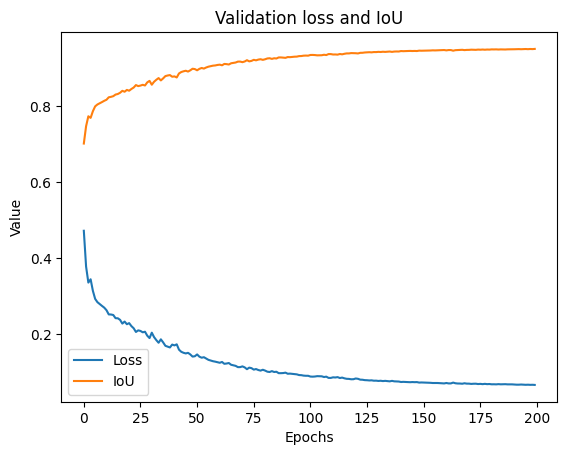

In [17]:
import pandas as pd
plt.title('Validation loss and IoU',)
valid_data = pd.DataFrame({'Loss':Loss_list["valid"], 'IoU':Accuracy_list["valid"]})
valid_data.to_csv(f'valid_data.csv')
sns.lineplot(data=valid_data,dashes=False)
plt.ylabel('Value')
plt.xlabel('Epochs')
plt.savefig('valid.png')

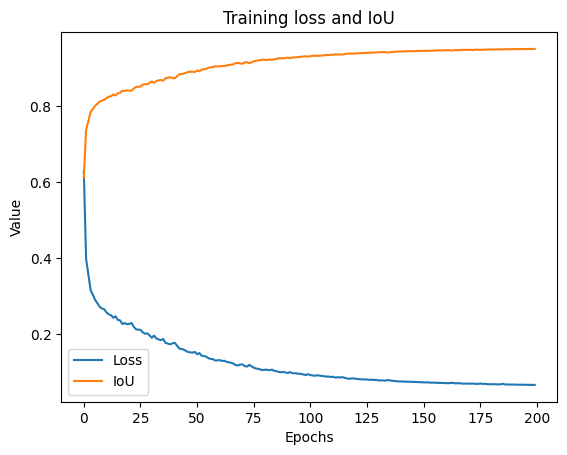

In [18]:
plt.figure()
plt.title('Training loss and IoU',)
valid_data = pd.DataFrame({'Loss':Loss_list["train"],'IoU':Accuracy_list["train"]})
valid_data.to_csv(f'train_data.csv')
sns.lineplot(data=valid_data,dashes=False)
plt.ylabel('Value')
plt.xlabel('Epochs')
plt.savefig('train.png')